In [22]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('C:/Users/suman/OneDrive/Bureau/Internship_Study/GNN_On_OdorPrediction/data/OdorSmiles_Updated.csv', encoding='ISO-8859-1')

# Drop non-label columns
labels_df = df.drop(columns=['SMILES', 'cas_number'])

# Filter: keep only odor descriptors with >10 positives
descriptor_counts = labels_df.sum(axis=0)
valid_descriptors = descriptor_counts[descriptor_counts > 10].index
filtered_labels_df = labels_df[valid_descriptors]
print(len(valid_descriptors))

# Count positive and negative labels
positive_counts = filtered_labels_df.sum(axis=0)
total_molecules = len(filtered_labels_df)
negative_counts = total_molecules - positive_counts

# formatted DataFrame
label_counts_df = pd.DataFrame({
    'Odor Descriptor': positive_counts.index,
    'Positive Count': positive_counts.values,
    'Negative Count': negative_counts.values
})

# Sort by positive count
label_counts_df = label_counts_df.sort_values(by='Positive Count', ascending=False).reset_index(drop=True)

# Save to text file
output_path = "positive_negative_label_counts.txt"
with open(output_path, "w") as f:
    f.write("Positive & Negative Label Counts per Odor Descriptor\n\n")
    f.write(label_counts_df.to_string(index=False))

print(f"\nSaved summary to: {output_path}")


266

Saved summary to: positive_negative_label_counts.txt


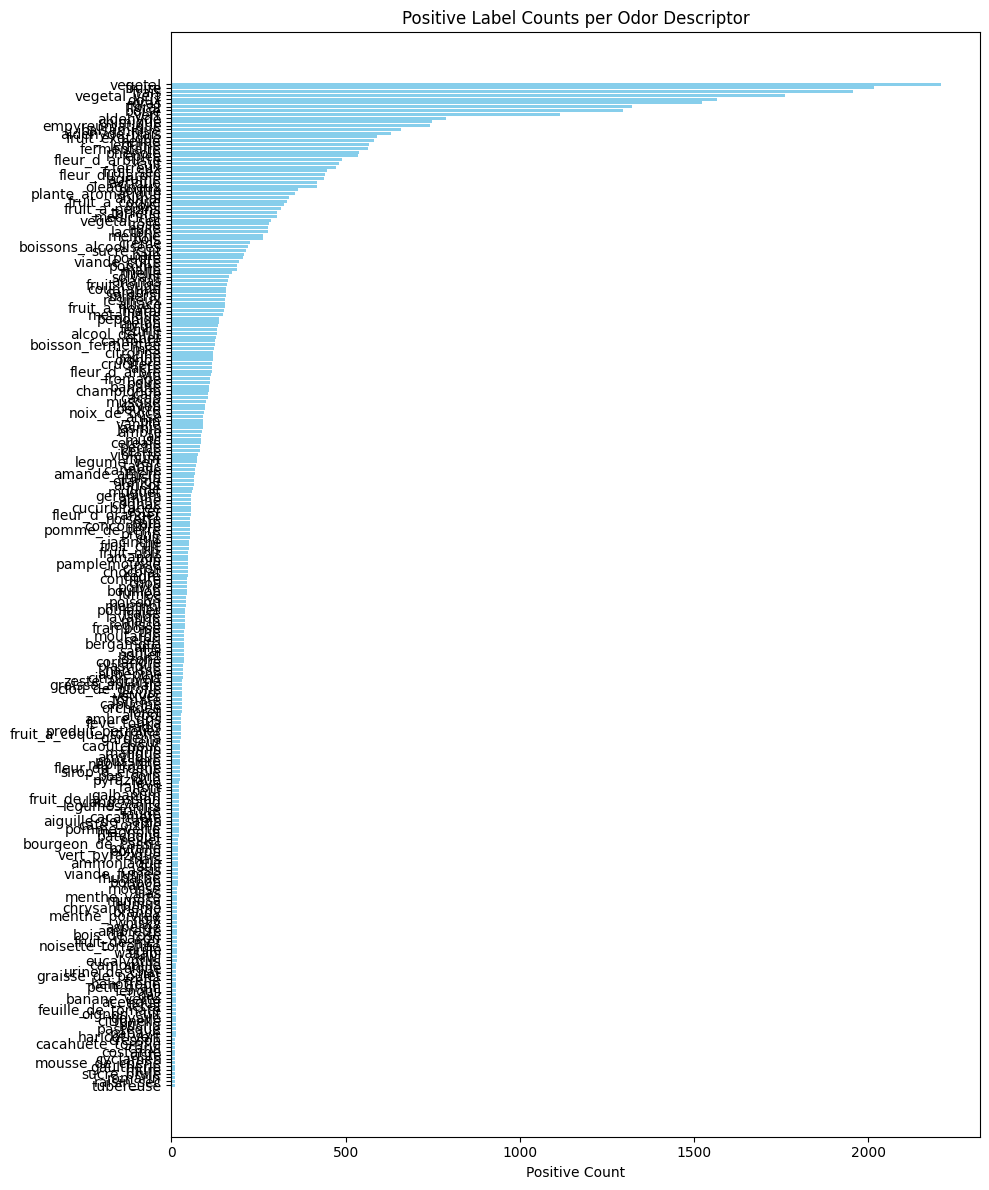

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plt.barh(label_counts_df['Odor Descriptor'], label_counts_df['Positive Count'], color='skyblue')
plt.gca().invert_yaxis()  # Most common at the top
plt.xlabel("Positive Count")
plt.title("Positive Label Counts per Odor Descriptor")
plt.tight_layout()
plt.show()
